# **Giới thiệu về Dataset Abalone**

Dataset Abalone là một tập dữ liệu phổ biến được sử dụng trong lĩnh vực học máy và thống kê để dự đoán tuổi của bào ngư dựa trên các đặc điểm vật lý của chúng. Dữ liệu này được thu thập từ các mẫu bào ngư và bao gồm nhiều thuộc tính khác nhau như kích thước, trọng lượng, và số vòng sinh trưởng trên vỏ bào ngư.

# **Mục tiêu của bài toán**

Mục tiêu chính của bài toán là xây dựng một mô hình học máy có khả năng dự đoán tuổi (rings) của bào ngư dựa trên các đặc điểm vật lý được cung cấp trong dataset. Việc dự đoán tuổi của bào ngư có thể giúp trong việc quản lý và bảo tồn nguồn tài nguyên biển, cũng như hỗ trợ trong các nghiên cứu sinh học liên quan đến bào ngư.


## **2.1 Chuẩn bị dữ liệu**
1. Chuẩn bị môi trường
   - Cài đặt các thư viện cần thiết: pandas, numpy, scikit-learn, matplotlib, seaborn.
   - Nhập các thư viện vào môi trường làm việc.
2. Tải dữ liệu
   - Tải dataset Abalone từ nguồn dữ liệu (ví dụ: UCI Machine Learning Repository).
   - Đọc dữ liệu vào DataFrame sử dụng pandas.
3. Khám phá sơ bộ dữ liệu
    - Hiển thị các thông tin cơ bản về dữ liệu (số lượng bản ghi, số lượng thuộc tính, kiểu dữ liệu).
    - Kiểm tra các giá trị thiếu và xử lý chúng nếu cần thiết.
    - Hiển thị một số bản ghi đầu tiên để hiểu cấu trúc dữ liệu.

4. Tiền xử lý dữ liệu
   - Chuyển đổi các biến phân loại (nếu có) thành dạng số sử dụng one-hot encoding hoặc label encoding.
   - Chuẩn hóa hoặc chuẩn hóa dữ liệu nếu cần thiết.
   - Kiểm tra và xử lý các giá trị ngoại lai (outliers) nếu cần thiết.

5. Chia dữ liệu thành 4 tập con:
- feature_train: tập mẫu huấn luyện.
- label_train: tập nhãn tương ứng với các mẫu trong feature_train.
- feature_test: tập mẫu kiểm tra có cấu trúc giống feature_train.
- label_test: tập nhãn tương ứng với các mẫu trong feature_test.

Shuffle dữ liệu trước khi chia và đảm bảo chia theo stratified fashion. Mỗi tỷ lệ chia (40/60, 60/40, 80/20, 90/10) sẽ tạo ra 16 tập con tổng cộng.

6. Trực quan hóa phân phối lớp trong tất cả các tập dữ liệu (tập gốc, tập huấn luyện và tập kiểm tra) để chứng minh rằng chúng đã được chuẩn bị đúng cách.

In [1]:
# 1. Import thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# 2. Load dataset Abalone
data = pd.read_csv('../data/abalone_original.csv')

# 3. Hiển thị thông tin cơ bản về dataset

print("Kích thước dataset:", data.shape)
print("\nThông tin về các cột trong dataset:")
print(data.info())
print("\n5 dòng đầu tiên của dataset:")
print(data.head())
print("\nMô tả thống kê của dataset:")
print(data.describe())

# Kiểm tra dữ liệu thiếu
print("\nKiểm tra dữ liệu thiếu:")
print(data.isnull().sum())


Kích thước dataset: (4177, 9)

Thông tin về các cột trong dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sex             4177 non-null   object 
 1   length          4177 non-null   int64  
 2   diameter        4177 non-null   int64  
 3   height          4177 non-null   int64  
 4   whole-weight    4177 non-null   float64
 5   shucked-weight  4177 non-null   float64
 6   viscera-weight  4177 non-null   float64
 7   shell-weight    4177 non-null   float64
 8   rings           4177 non-null   int64  
dtypes: float64(4), int64(4), object(1)
memory usage: 293.8+ KB
None

5 dòng đầu tiên của dataset:
  sex  length  diameter  height  whole-weight  shucked-weight  viscera-weight  \
0   M      91        73      19         102.8            44.9            20.2   
1   M      70        53      18          45.1            19.9          

In [2]:
# 4. Tiền xử lý dữ liệu
# Kiểm tra bao nhiêu loại trong cột categorical
for col in data.select_dtypes(include=['object']).columns:
    print(f"\nCột '{col}' có {data[col].nunique()} loại: {data[col].unique()}")

# Sử dụng one-hot encoding cho cột categorical sex, mã hóa thành 0 và 1 thay vì true false
data = pd.get_dummies(data, columns=['sex'], drop_first=False, dtype=int)   
print("\nDữ liệu sau khi tiền xử lý:")
print(data.head())


Cột 'sex' có 3 loại: ['M' 'F' 'I']

Dữ liệu sau khi tiền xử lý:
   length  diameter  height  whole-weight  shucked-weight  viscera-weight  \
0      91        73      19         102.8            44.9            20.2   
1      70        53      18          45.1            19.9             9.7   
2     106        84      27         135.4            51.3            28.3   
3      88        73      25         103.2            43.1            22.8   
4      66        51      16          41.0            17.9             7.9   

   shell-weight  rings  sex_F  sex_I  sex_M  
0          30.0     15      0      0      1  
1          14.0      7      0      0      1  
2          42.0      9      1      0      0  
3          31.0     10      0      0      1  
4          11.0      7      0      1      0  


In [3]:
# 5. Chia dữ liệu thành tập huấn luyện và tập kiểm tra
# Tỉ lệ tập train để thử nghiệm
ratio_train = [0.4, 0.6, 0.8, 0.9]
features_train = {}
labels_train = {}
features_test = {}
labels_test = {}
for ratio in ratio_train:
    # Shuffle trước khi chia
    data = data.sample(frac=1, random_state=42).reset_index(drop=True)
    X = data.drop('rings', axis=1)
    y = data['rings']
    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=ratio, random_state=42)
    features_train[ratio] = X_train
    labels_train[ratio] = y_train
    features_test[ratio] = X_test
    labels_test[ratio] = y_test
    print(f"\nTỉ lệ tập huấn luyện: {ratio}")
    print("Kích thước tập huấn luyện:", X_train.shape)
    print("Kích thước tập kiểm tra:", X_test.shape)
  



Tỉ lệ tập huấn luyện: 0.4
Kích thước tập huấn luyện: (1670, 10)
Kích thước tập kiểm tra: (2507, 10)

Tỉ lệ tập huấn luyện: 0.6
Kích thước tập huấn luyện: (2506, 10)
Kích thước tập kiểm tra: (1671, 10)

Tỉ lệ tập huấn luyện: 0.8
Kích thước tập huấn luyện: (3341, 10)
Kích thước tập kiểm tra: (836, 10)

Tỉ lệ tập huấn luyện: 0.9
Kích thước tập huấn luyện: (3759, 10)
Kích thước tập kiểm tra: (418, 10)


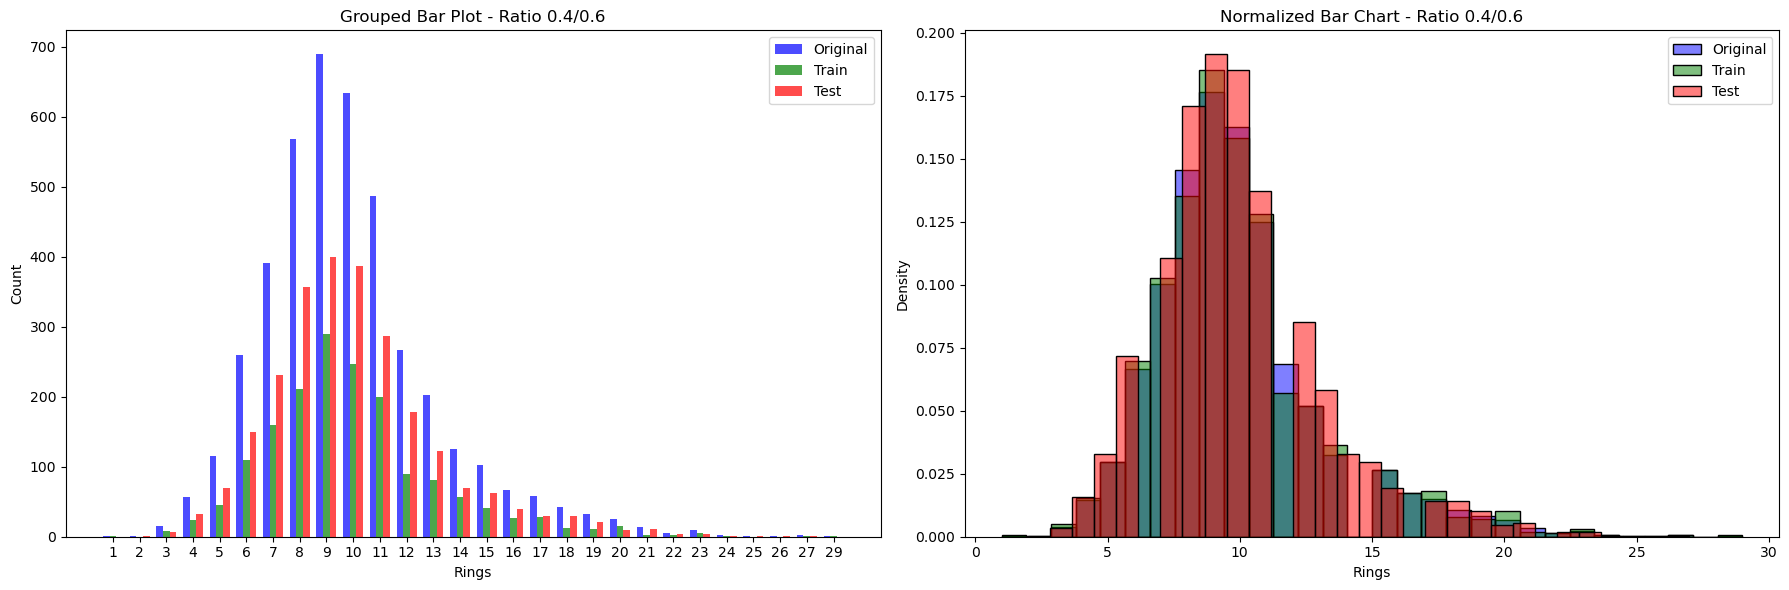

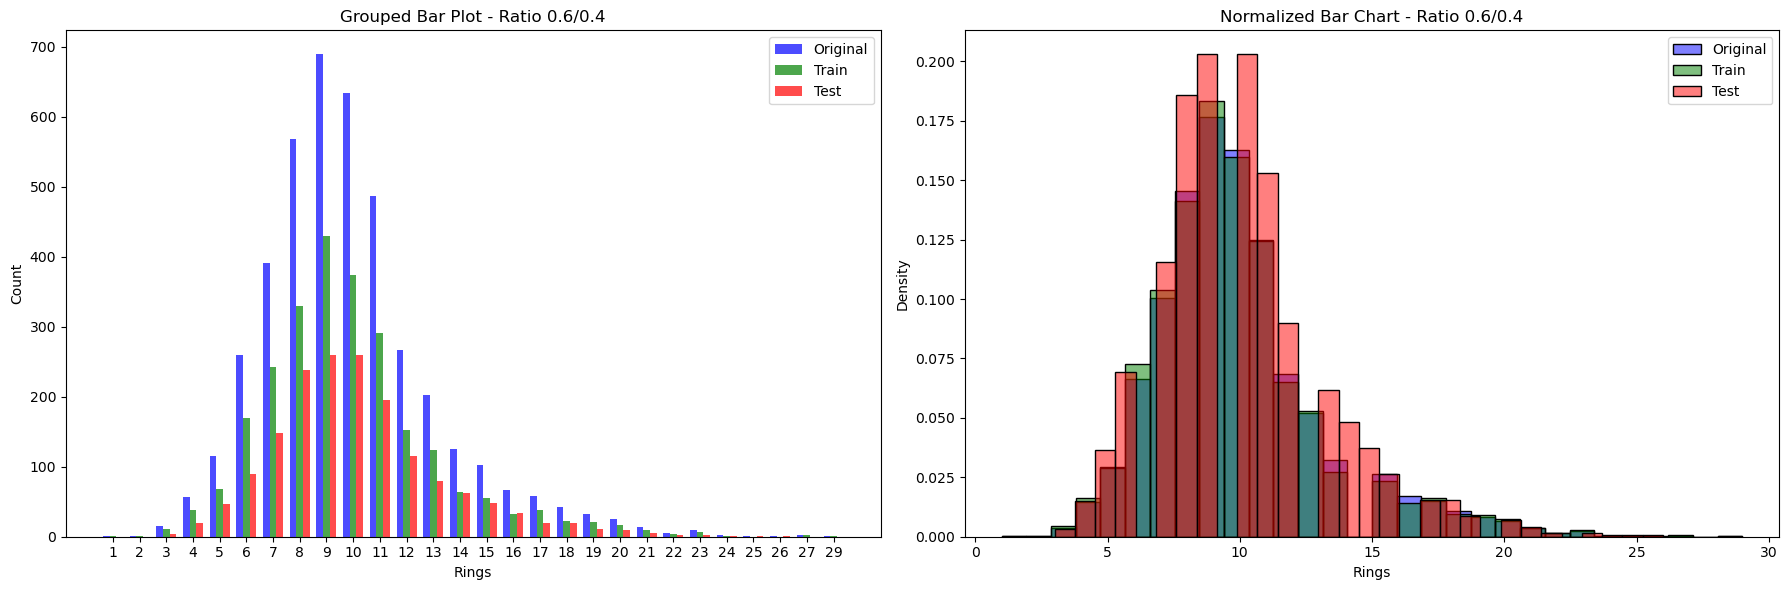

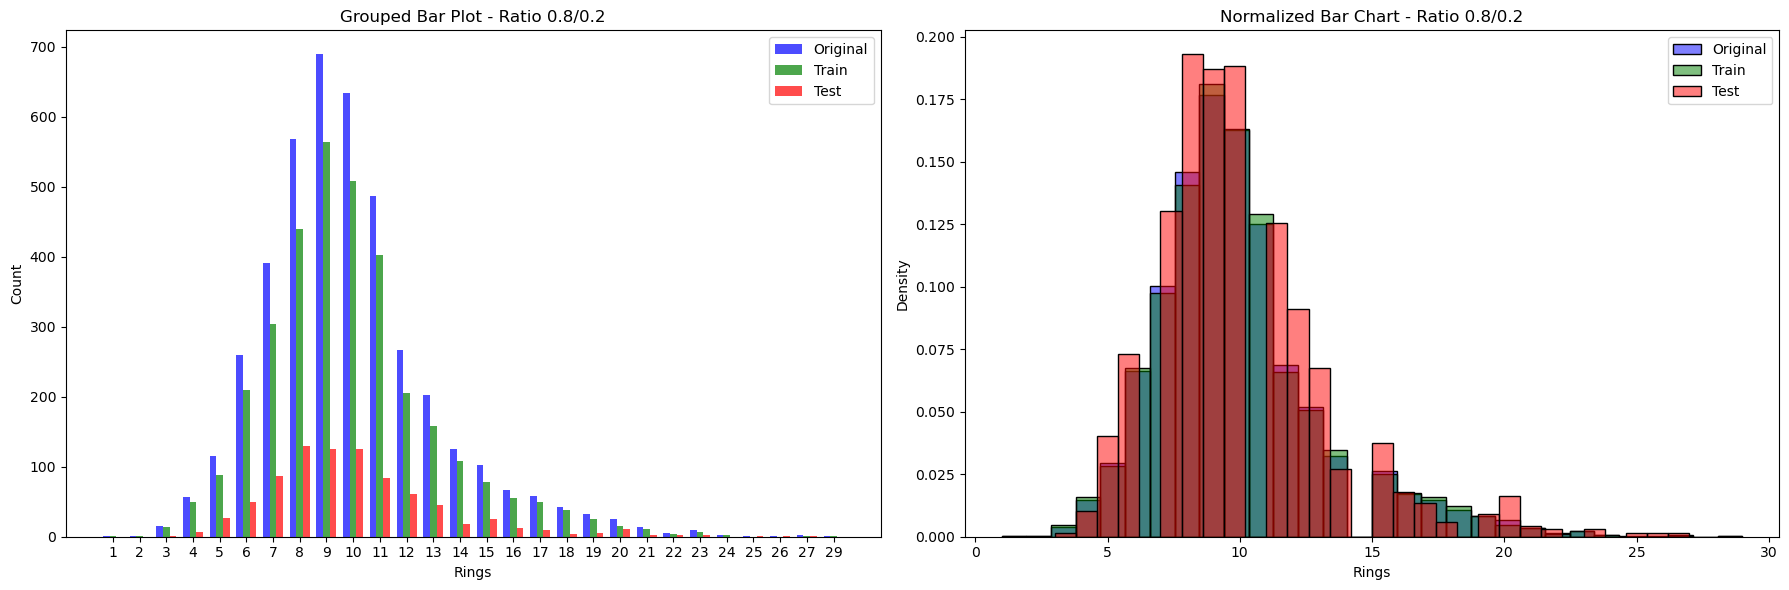

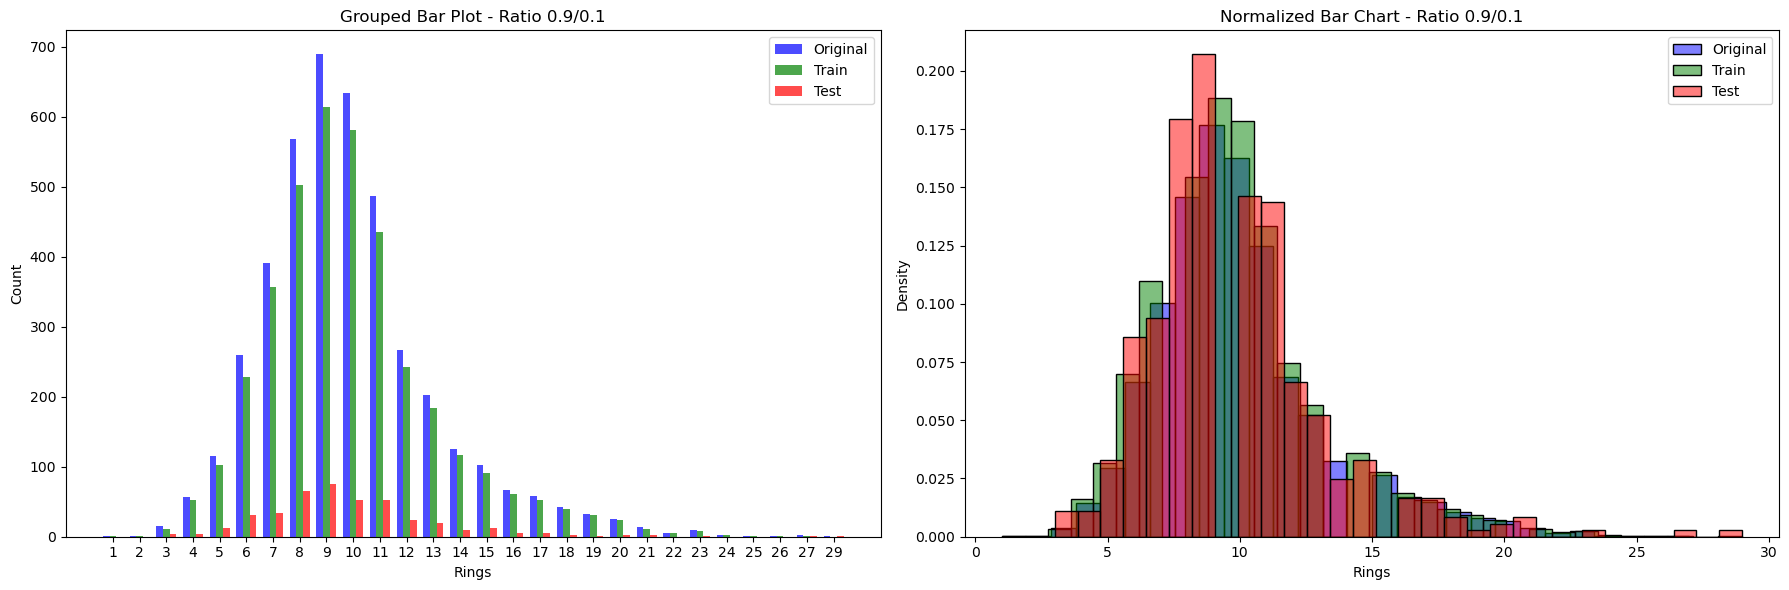

In [4]:
# 6. Trực quan hóa các tập sau khi chia. Tập original, tập train, tập test
# Visualize với 2 subplots cho mỗi tỉ lệ: grouped bar plot và normalized bar chart
for ratio in ratio_train:
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # Subplot 1: Grouped bar plot for counts
    all_rings = sorted(data['rings'].unique())
    original_counts = data['rings'].value_counts().reindex(all_rings, fill_value=0)
    train_counts = labels_train[ratio].value_counts().reindex(all_rings, fill_value=0)
    test_counts = labels_test[ratio].value_counts().reindex(all_rings, fill_value=0)
    width = 0.25
    x = np.arange(len(all_rings))
    axes[0].bar(x - width, original_counts, width, label='Original', color='blue', alpha=0.7)
    axes[0].bar(x, train_counts, width, label='Train', color='green', alpha=0.7)
    axes[0].bar(x + width, test_counts, width, label='Test', color='red', alpha=0.7)
    axes[0].set_xlabel('Rings')
    axes[0].set_ylabel('Count')
    axes[0].set_title(f'Grouped Bar Plot - Ratio {ratio}/{round(1 - ratio, 2)}')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(all_rings)
    axes[0].legend()

    # Subplot 2: Normalized bar chart
    sns.histplot(data['rings'], label='Original', stat='density', alpha=0.5, bins=30, color='blue', ax=axes[1])
    sns.histplot(labels_train[ratio], label='Train', stat='density', alpha=0.5, bins=30, color='green', ax=axes[1])
    sns.histplot(labels_test[ratio], label='Test', stat='density', alpha=0.5, bins=30, color='red', ax=axes[1])
    axes[1].set_title(f'Normalized Bar Chart - Ratio {ratio}/{round(1 - ratio, 2)}')
    axes[1].set_xlabel('Rings')
    axes[1].set_ylabel('Density')
    axes[1].legend()

    plt.tight_layout()
    plt.show()


In [5]:
import os

# import đường dẫn dot.exe để tránh lỗi khi vẽ hình bằng graphviz
path_to_graphviz = r"D:\PROGRAM FILE\Anaconda\envs\min_ds-env\Library\bin"
path_to_graphviz_sub = r"D:\PROGRAM FILE\Anaconda\envs\min_ds-env\Library\bin\graphviz"

# Kiểm tra và thêm vào PATH
if os.path.exists(os.path.join(path_to_graphviz, 'dot.exe')):
    os.environ["PATH"] += os.pathsep + path_to_graphviz
    print("Đã tìm thấy dot.exe ở thư mục 'bin'. Đã sửa lỗi xong!")
    
elif os.path.exists(os.path.join(path_to_graphviz_sub, 'dot.exe')):
    os.environ["PATH"] += os.pathsep + path_to_graphviz_sub
    print("Đã tìm thấy dot.exe ở thư mục 'bin/graphviz'. Đã sửa lỗi xong!")
    
else:
    print("Vẫn chưa thấy file dot.exe. Bạn có chắc chắn đã chạy 'conda install graphviz' chưa?")

Đã tìm thấy dot.exe ở thư mục 'bin/graphviz'. Đã sửa lỗi xong!


## **2.2 Xây dựng các bộ phân loại Decision Tree**

1.  Sử dụng thư viện scikit-learn và lớp sklearn.tree.DecisionTreeClassifier với tiêu chí là Information Gain (entropy) để xây dựng các bộ phân loại Decision Tree.
2. Huấn luyện các mô hình trên tập huấn luyện (feature_train, label_train) cho mỗi tỷ lệ chia dữ liệu.
3.  Trực quan hóa cây: Sử dụng Graphviz để vẽ sơ đồ cây quyết định kết quả cho từng trường hợp


In [6]:
# 1. import Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
# 2. Xây dựng và huấn luyện các bộ phân loại Decision Tree
models = {}
for ratio in ratio_train:
    clf = DecisionTreeClassifier(random_state=42)
    clf.fit(features_train[ratio], labels_train[ratio])
    models[ratio] = clf
    max_depth = 3
    print(f"\nĐã huấn luyện Decision Tree cho tỉ lệ tập huấn luyện: {ratio}")



Đã huấn luyện Decision Tree cho tỉ lệ tập huấn luyện: 0.4

Đã huấn luyện Decision Tree cho tỉ lệ tập huấn luyện: 0.6

Đã huấn luyện Decision Tree cho tỉ lệ tập huấn luyện: 0.8

Đã huấn luyện Decision Tree cho tỉ lệ tập huấn luyện: 0.9


Đang vẽ hình cho tỉ lệ: 0.4...


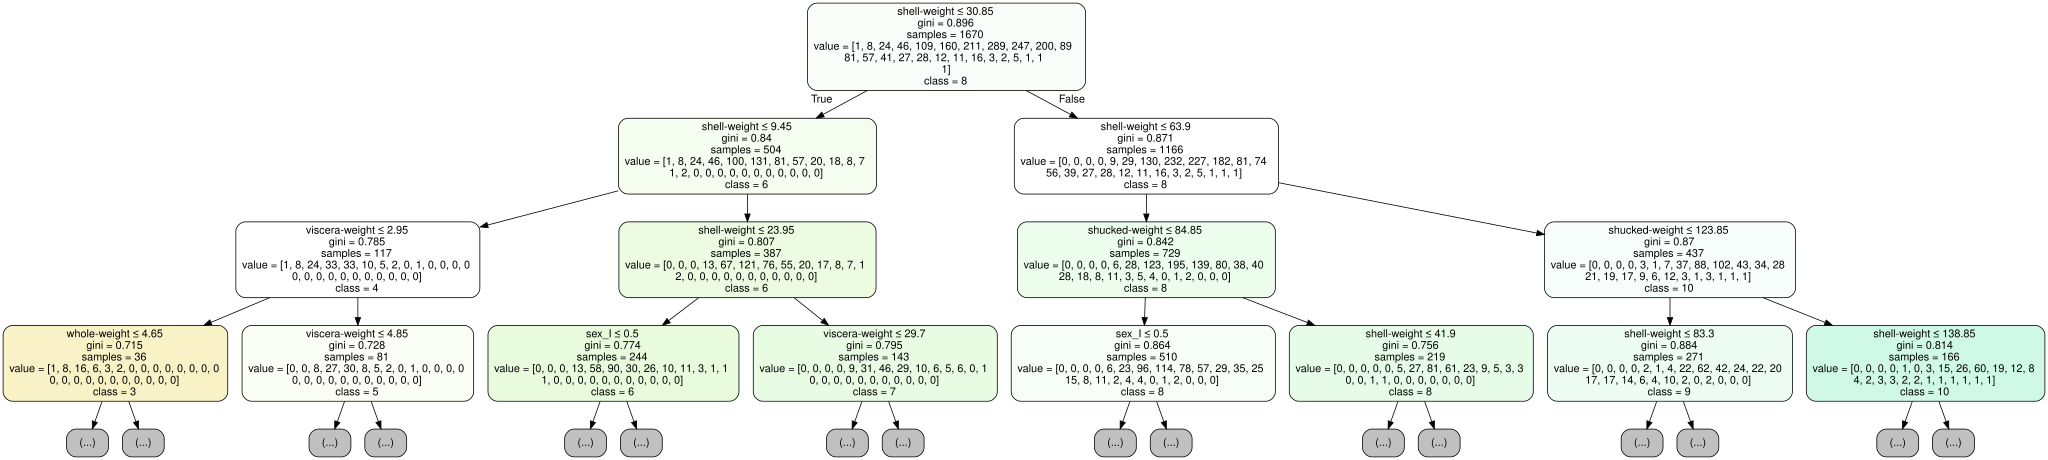

Đang vẽ hình cho tỉ lệ: 0.6...


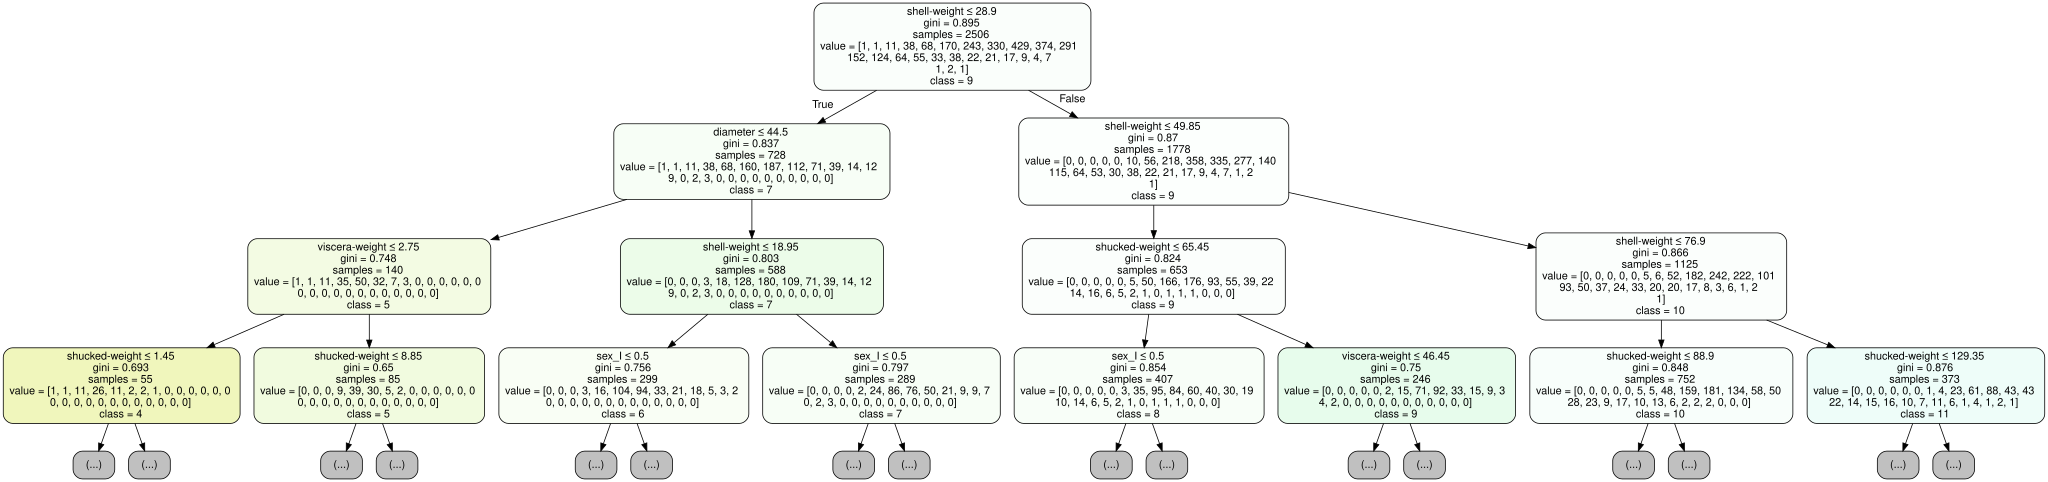

Đang vẽ hình cho tỉ lệ: 0.8...


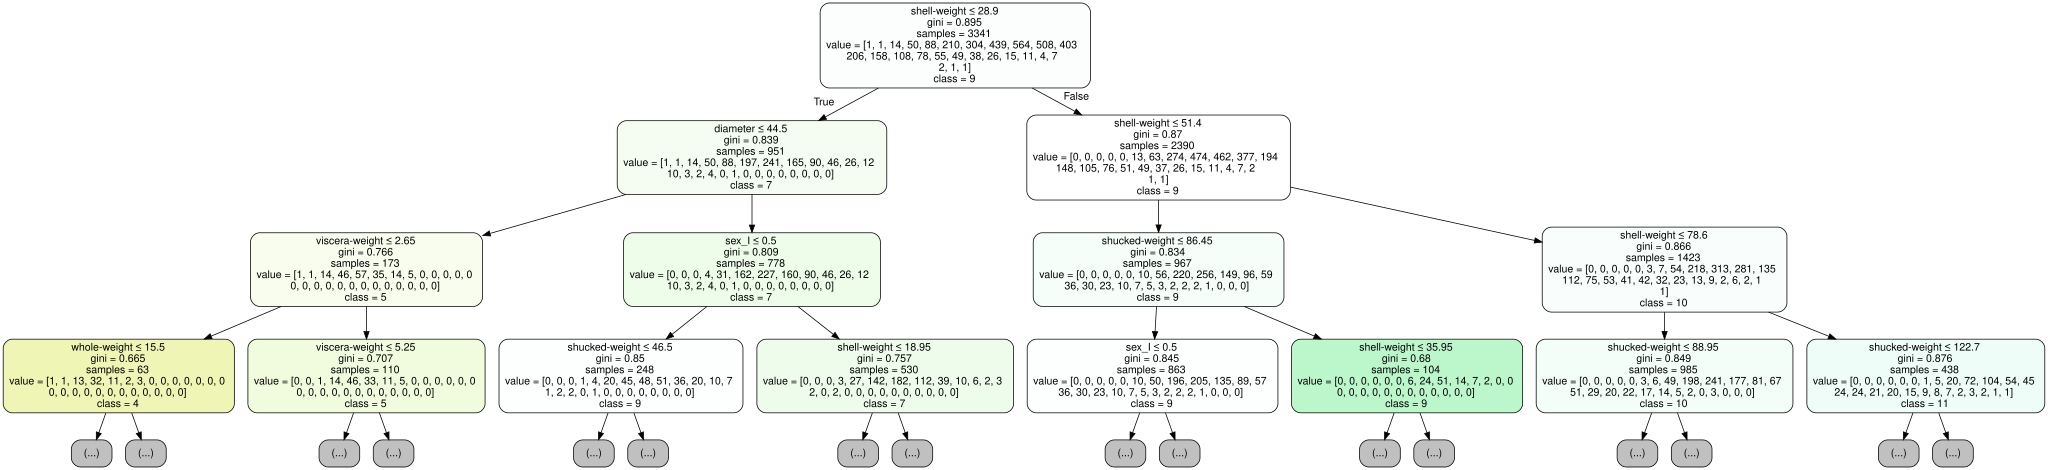

Đang vẽ hình cho tỉ lệ: 0.9...


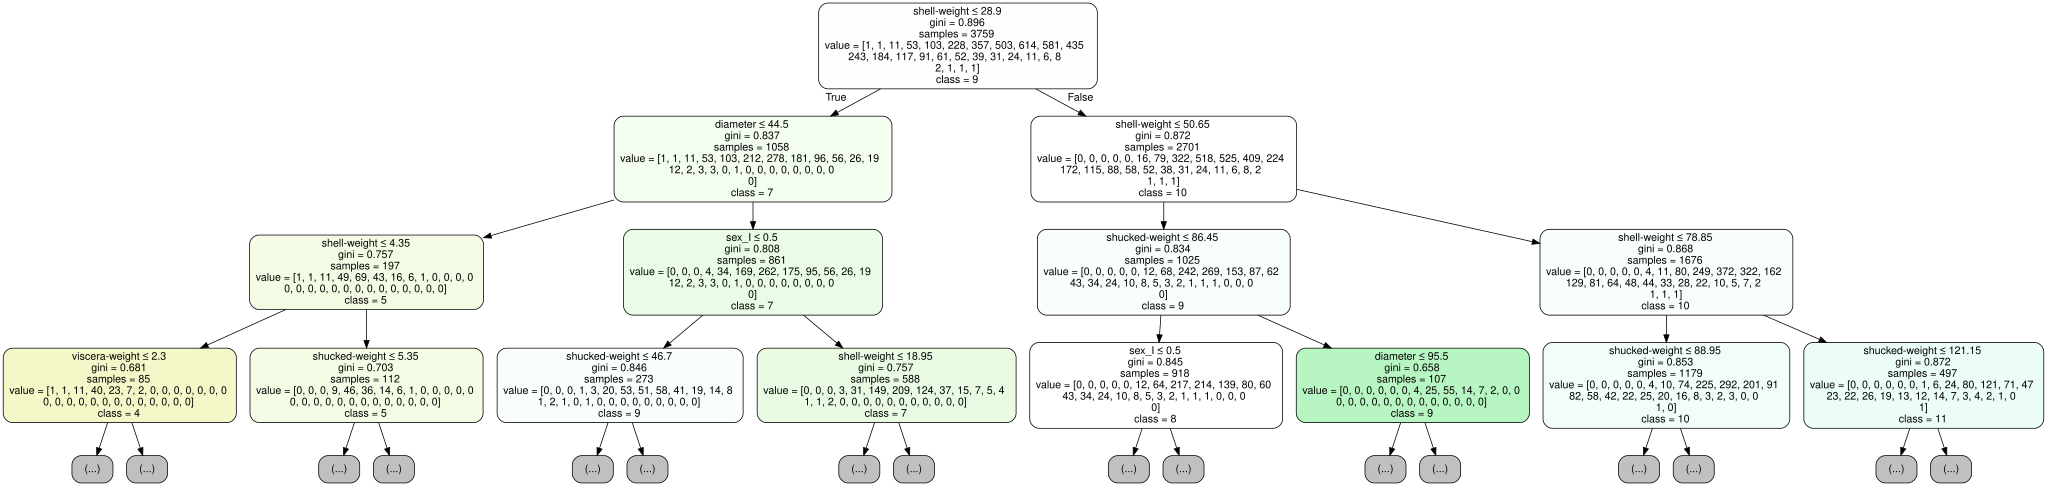

In [7]:
# 3. Trực quan hóa sử dụng Graphviz
from sklearn.tree import export_graphviz
import graphviz
from IPython.display import display

feature_names = list(features_train[ratio_train[0]].columns)
class_names = [str(c) for c in sorted(data['rings'].unique())]

for ratio, model in models.items():
    print(f"Đang vẽ hình cho tỉ lệ: {ratio}...")
    
    # Xuất dữ liệu cây ra định dạng DOT
    dot_data = export_graphviz(
        model,
        out_file=None,
        feature_names=feature_names,  # Tên cột để dễ đọc
        class_names=class_names,      # Tên lớp (nhãn mục tiêu)
        filled=True,                  # Tô màu node theo lớp chiếm ưu thế
        rounded=True,                 # Bo tròn góc
        special_characters=True,
        max_depth=3                   # Giới hạn độ sâu để hình dễ nhìn hơn
)
    
    # Hiển thị trực tiếp trong notebook (SVG)
    graph = graphviz.Source(dot_data, format='svg')
    display(graph)

## **2.3 Đánh giá mô hình**

1. Sử dụng Classification_report và confusion_matrix đánh giá hiệu suất của các mô hình trên tập kiểm tra (feature_test, label_test) cho mỗi tỷ lệ chia dữ liệu.
2. So sánh và phân tích hiệu suất của các mô hình Decision Tree dựa trên các tỷ lệ chia dữ liệu khác nhau. Xem xét các chỉ số như accuracy, precision, recall và F1-score để đánh giá mô hình.
3.  Phân tích: Giải thích ý nghĩa của báo cáo phân loại và confusion matrix, từ đó đưa ra những hiểu biết (insights) về hiệu suất của các bộ phân loại này

In [8]:
from sklearn.metrics import classification_report
# 1. Đánh giá mô hình trên tập kiểm tra
for ratio in ratio_train:
    clf = models[ratio]
    y_pred = clf.predict(features_test[ratio])
    print(f"\nĐánh giá mô hình cho tỉ lệ tập huấn luyện: {ratio}")
    print("Classification Report:")
    print(classification_report(labels_test[ratio], y_pred, zero_division=0))



Đánh giá mô hình cho tỉ lệ tập huấn luyện: 0.4
Classification Report:
              precision    recall  f1-score   support

           2       0.00      0.00      0.00         1
           3       0.33      0.29      0.31         7
           4       0.26      0.30      0.28        33
           5       0.27      0.30      0.29        69
           6       0.29      0.25      0.27       150
           7       0.22      0.27      0.24       231
           8       0.24      0.21      0.23       357
           9       0.23      0.27      0.25       400
          10       0.22      0.21      0.22       387
          11       0.18      0.21      0.19       287
          12       0.12      0.10      0.11       178
          13       0.09      0.08      0.08       122
          14       0.10      0.09      0.09        69
          15       0.04      0.03      0.03        62
          16       0.06      0.05      0.06        40
          17       0.09      0.10      0.10        30
          

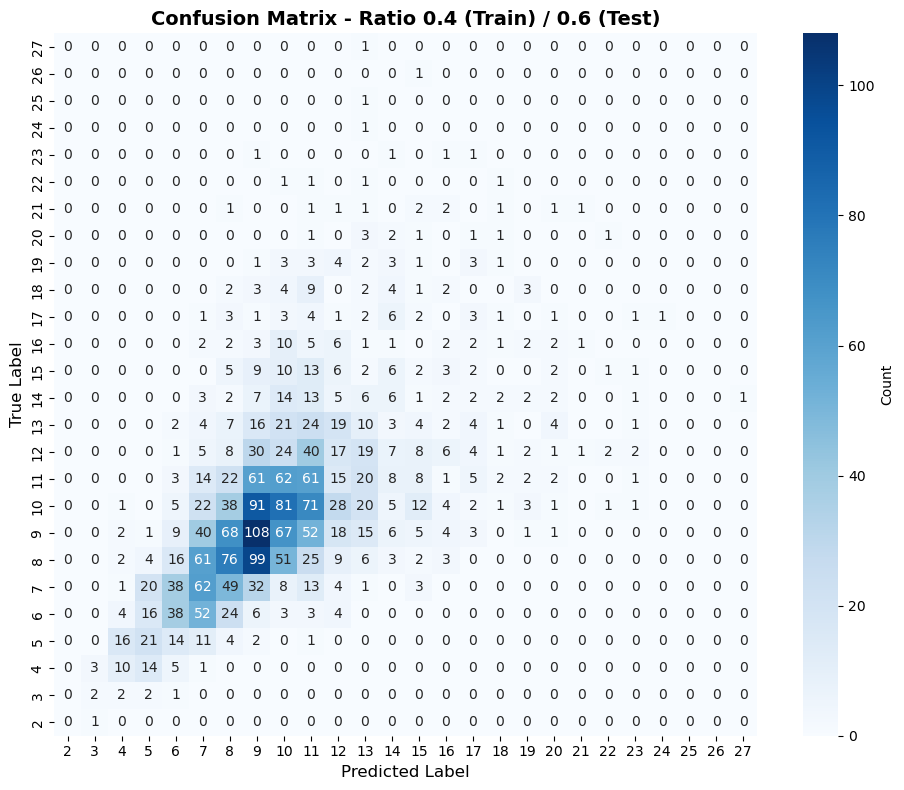

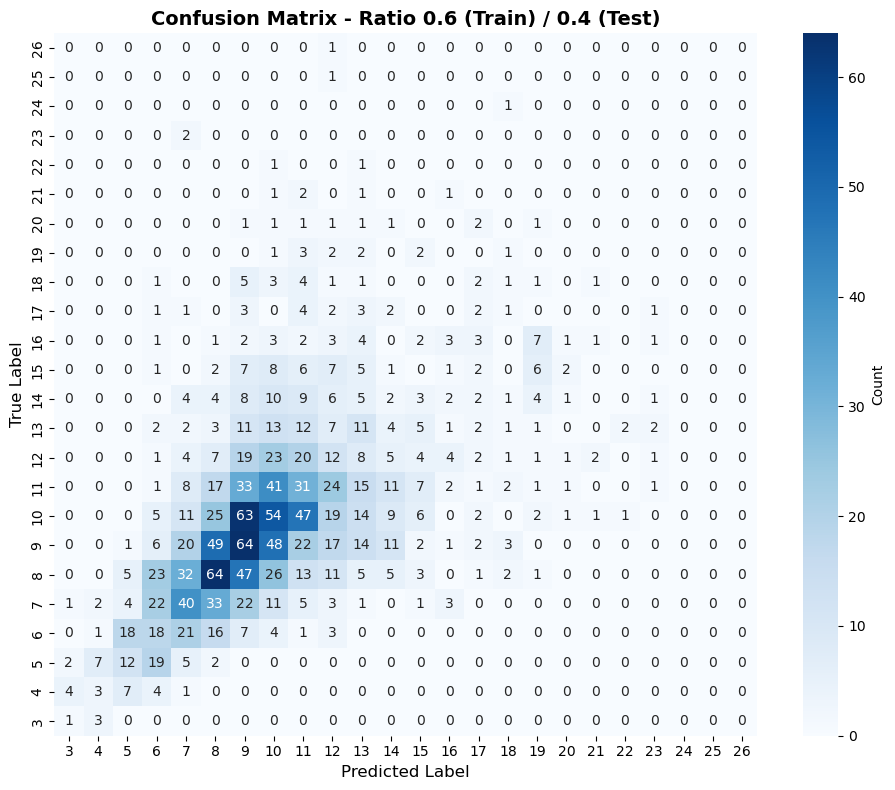

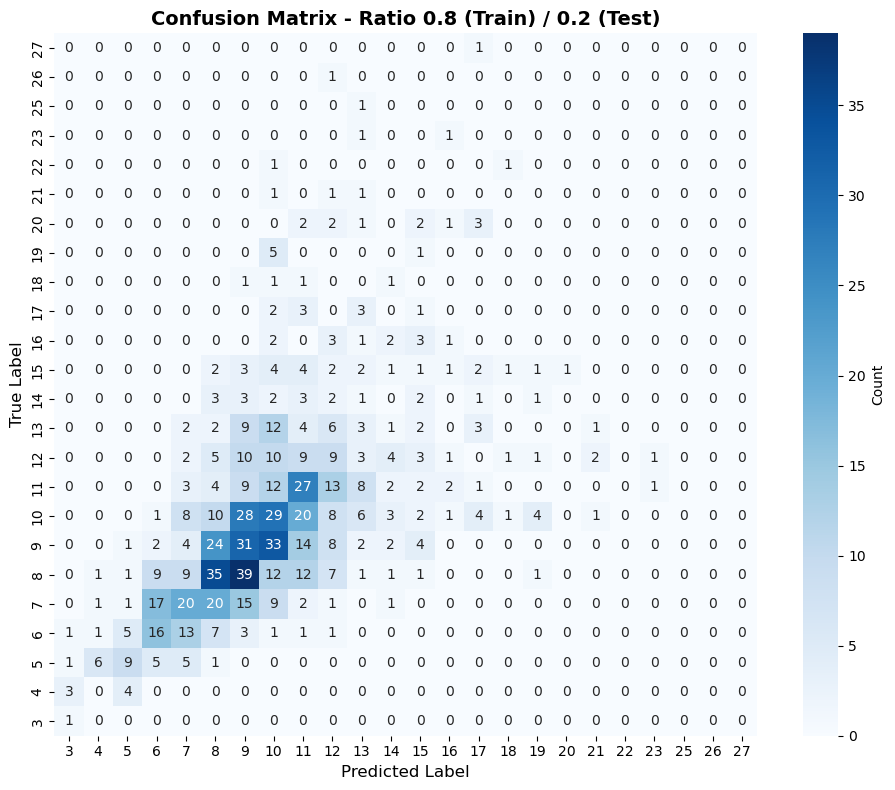

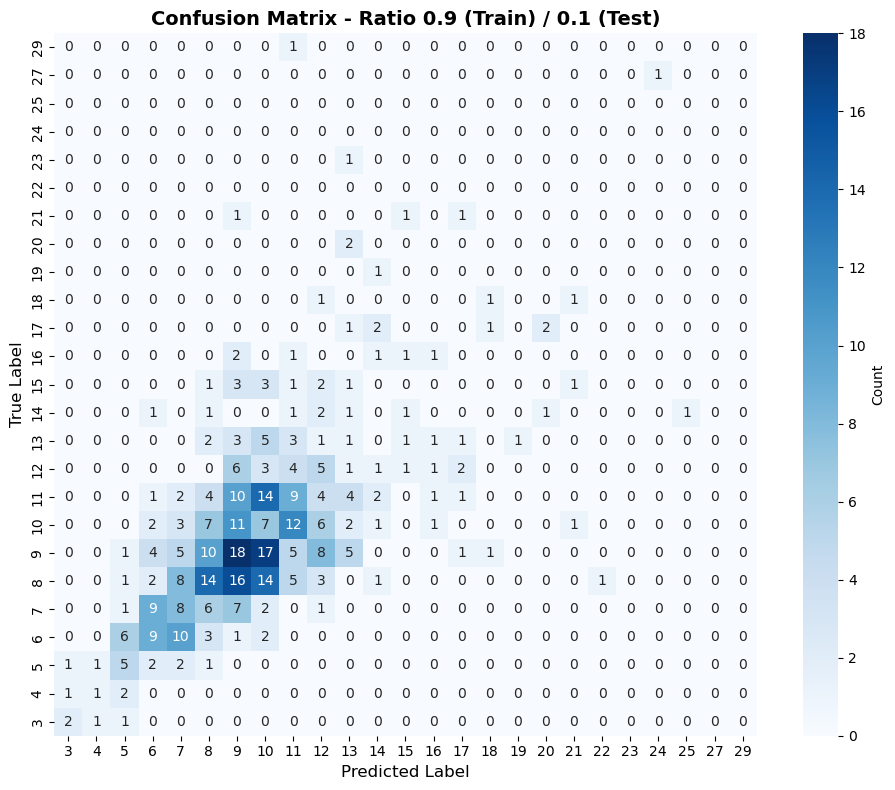

In [9]:
# 1. Vẽ confusion matrix
from sklearn.metrics import confusion_matrix

# Vẽ riêng từng confusion matrix với kích thước lớn hơn
for ratio in ratio_train:
    clf = models[ratio]
    y_pred = clf.predict(features_test[ratio])
    
    # Lấy unique classes từ test set
    unique_classes = sorted(set(labels_test[ratio].unique()) | set(y_pred))
    
    # Tính confusion matrix
    cm = confusion_matrix(labels_test[ratio], y_pred, labels=unique_classes)
    
    # Đảo hàng của confusion matrix để khớp với nhãn đảo
    cm_flipped = cm[::-1, :]
    
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm_flipped, annot=True, fmt='d', cmap='Blues', ax=ax, 
                cbar_kws={'label': 'Count'},
                xticklabels=unique_classes, 
                yticklabels=unique_classes[::-1],
                square=True)
    ax.set_title(f'Confusion Matrix - Ratio {ratio} (Train) / {round(1-ratio, 2)} (Test)', 
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)
    plt.tight_layout()
    plt.show()


### Diễn giải báo cáo phân loại và confusion matrix, từ đó đưa ra những hiểu biết (insights) về hiệu suất của các bộ phân loại này

#### 1. **Diễn giải Classification Report**

**Đánh giá Hiệu suất chung (Overall Performance)**: Tổng quan về hiệu suất của mô hình qua các chỉ số chính như accuracy, macro avg, weighted avg.

- Độ chính xác (Accuracy): Kết quả thực tế cho thấy độ chính xác rất thấp, chỉ dao động trong khoảng 19% - 22% trên các tập kiểm thử.
- Ý nghĩa: Điều này có nghĩa là mô hình chỉ dự đoán đúng chính xác số tuổi (Rings) trong khoảng 1/5 trường hợp. Đây là mức hiệu suất không khả dụng cho bài toán thực tế nếu yêu cầu độ chính xác tuyệt đối.

**Chi tiết từ Classification Report**: 

- Các lớp phổ biến (Rings 8-11): Có điểm F1-score tốt hơn các lớp khác (dao động 0.2 - 0.3) do có lượng dữ liệu mẫu (Support) lớn hơn.
- Các lớp biên (Rings < 5 hoặc > 20): Precision và Recall thường về 0. Mô hình gần như thất bại hoàn toàn trong việc nhận diện các bào ngư quá non hoặc quá già.
- Nguyên nhân: Hiện tượng Mất cân bằng dữ liệu (Class Imbalance) nghiêm trọng khiến mô hình thiên vị các lớp đa số và bỏ qua các lớp thiểu số.

#### 2. **Diễn giải Confusion Matrix**

- Đường chéo phụ: Các dự đoán chính xác - giá trị càng cao càng tốt. Các dự doán chính xác tập trung chủ yếu ở các lớp trung gian (Rings 8-11).

- Phân bố lỗi lân cận: 
    + Lỗi tập trung ở các lớp gần nhau (ví dụ: nhầm rings=8 thành rings=9) cho thấy đây là lỗi hợp lý do tương đồng đặc trưng
    + Lỗi phân tán rộng cho thấy mô hình chưa học được pattern rõ ràng

#### 3. **Kết luận**

- Cấu trúc dữ liệu Abalone không phù hợp cho bài toán phân loại đa lớp (Multi-class Classification) với Decision Tree thuần túy nếu giữ nguyên 29 lớp tuổi:
    + Dữ liệu chồng chéo: Các độ tuổi lân cận (ví dụ 9 và 10) có đặc điểm vật lý y hệt nhau, khiến việc thêm dữ liệu train không giúp ích.
    + Mất cân bằng: Mô hình luôn bị bias về lớp đa số, bất kể tỉ lệ train/test.
    
- Đề xuất cải tiến: Thay vì dự đoán chính xác số Rings (29 class), nên gom nhóm lại thành 3 khoảng tuổi (Young, Adult, Old) hoặc chuyển sang bài toán Hồi quy (Regression) để giảm thiểu sai số dự đoán.

## **2.4 Phân tích sự ảnh hưởng của độ sâu cây (chỉ thực hiện trên tỷ lệ 80/20)**

1. Thực hiện thí nghiệm bằng cách huấn luyện các mô hình Decision Tree với các độ sâu khác nhau (None, 2, 3, 4, 5, 6, 7)
2. Trực quan hóa: Vẽ sơ đồ cây bằng Graphviz cho từng giá trị max_depth
3. Ghi nhận kết quả: Lập bảng thống kê độ chính xác (accuracy_score) trên tập kiểm tra ứng với từng giá trị độ sâu
4. Biểu đồ và nhận xét: Cung cấp các biểu đồ thống kê và đưa ra nhận định về việc độ sâu ảnh hưởng như thế nào đến độ chính xác. 

In [10]:
# 1. Phân tích hiệu suất trên các max_depth khác nhau
from sklearn.metrics import accuracy_score
import pandas as pd

results = []
max_depths = [None, 2, 3, 4, 5, 6, 7]
ratio = 0.8  # Chỉ thực hiện trên tỷ lệ 80/20

for max_depth in max_depths:
    clf = DecisionTreeClassifier(criterion='entropy', random_state=42, max_depth=max_depth)
    clf.fit(features_train[ratio], labels_train[ratio])
    y_pred = clf.predict(features_test[ratio])
    accuracy = accuracy_score(labels_test[ratio], y_pred)
    results.append({
        'Ratio': ratio,
        'Max Depth': max_depth if max_depth else 'None',
        'Accuracy': accuracy
    })

Decision Tree - Max Depth: None


Decision Tree - Max Depth: 2


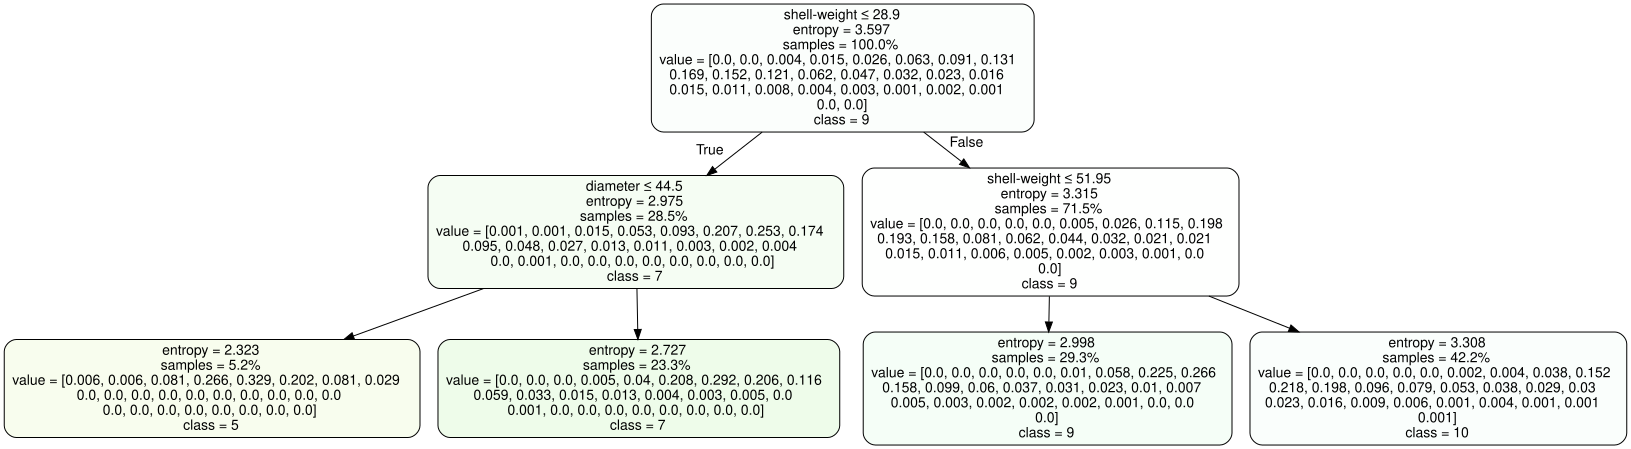

Decision Tree - Max Depth: 3


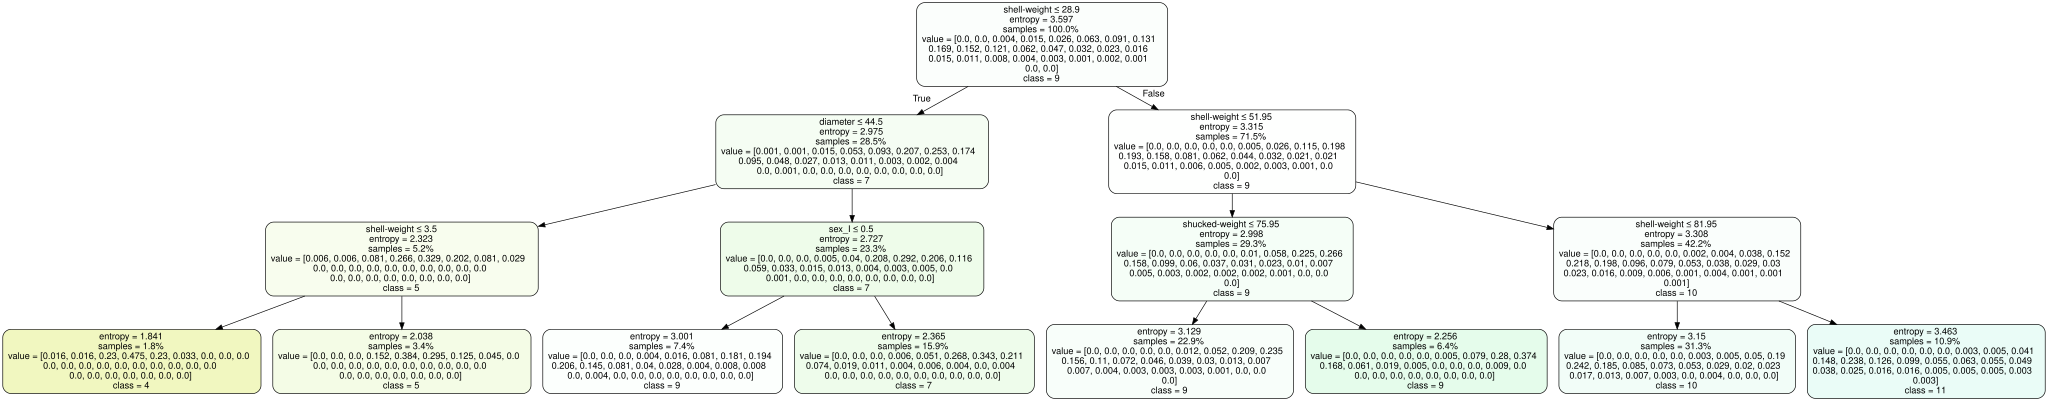

Decision Tree - Max Depth: 4


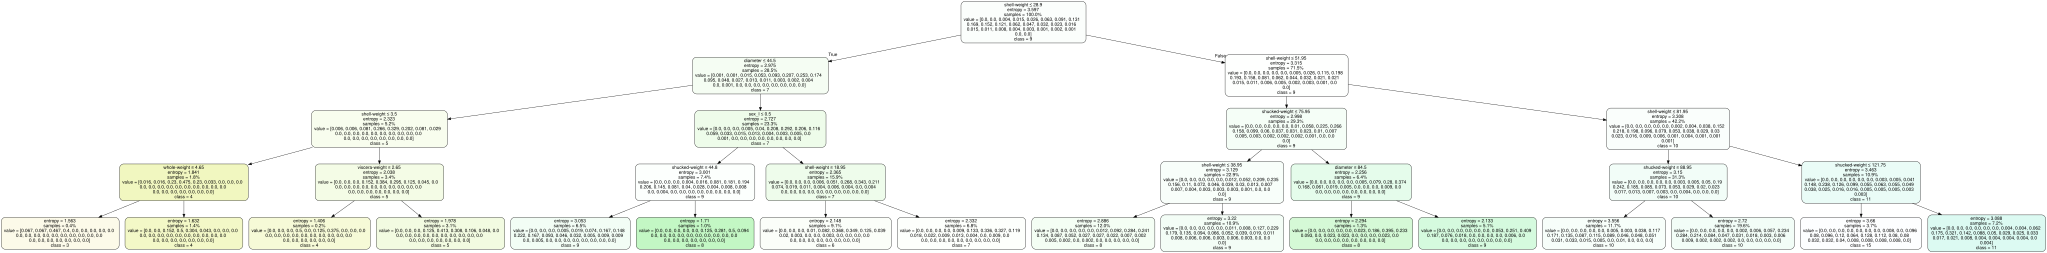

Decision Tree - Max Depth: 5


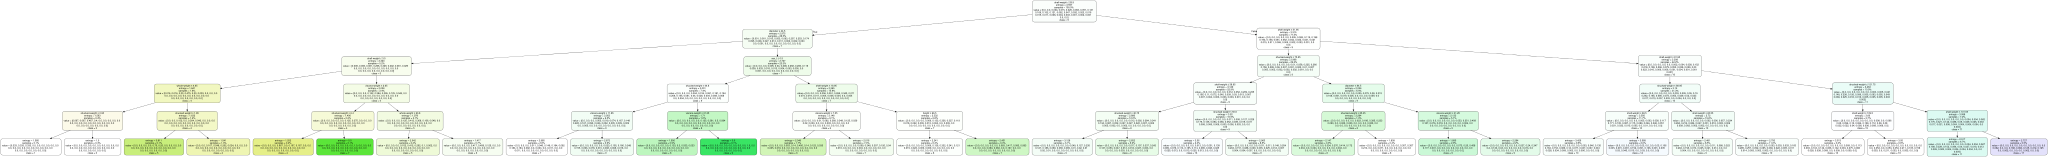

Decision Tree - Max Depth: 6


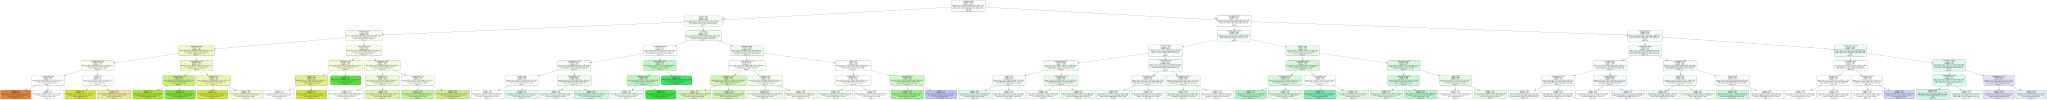

Decision Tree - Max Depth: 7


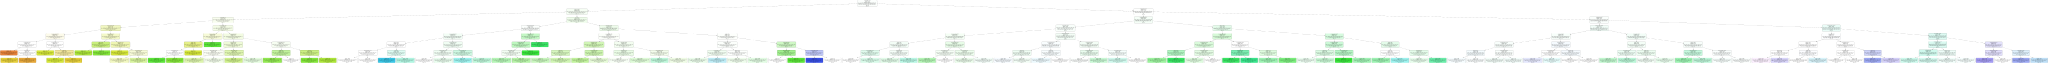

In [11]:
# 2. Vẽ sơ đồ cây bằng Graphviz cho từng giá trị max_depth
from sklearn.tree import export_graphviz
import graphviz
from IPython.display import display

feature_names = list(features_train[ratio_train[0]].columns)
class_names = [str(cls) for cls in sorted(data['rings'].unique())]

for max_depth in max_depths:
    clf = DecisionTreeClassifier(criterion='entropy', random_state=42, max_depth=max_depth)
    clf.fit(features_train[ratio], labels_train[ratio])
    
    print(f'Decision Tree - Max Depth: {max_depth if max_depth else "None"}')
    
    # Xuất dữ liệu cây ra định dạng DOT
    dot_data = export_graphviz(
        clf,
        out_file=None,
        feature_names=feature_names,
        class_names=class_names,
        filled=True,
        rounded=True,
        special_characters=True,
        proportion=True,
        max_depth=max_depth  # Không giới hạn thêm, hiển thị full depth
)
    
    # Hiển thị trực tiếp trong notebook (SVG)
    graph = graphviz.Source(dot_data, format='svg')
    display(graph)

In [12]:
results_df = pd.DataFrame(results)
print("Kết quả Accuracy với các max_depth khác nhau:")
print(results_df.to_string(index=False))

Kết quả Accuracy với các max_depth khác nhau:
 Ratio Max Depth  Accuracy
   0.8      None  0.198565
   0.8         2  0.246411
   0.8         3  0.253589
   0.8         4  0.251196
   0.8         5  0.240431
   0.8         6  0.236842
   0.8         7  0.245215


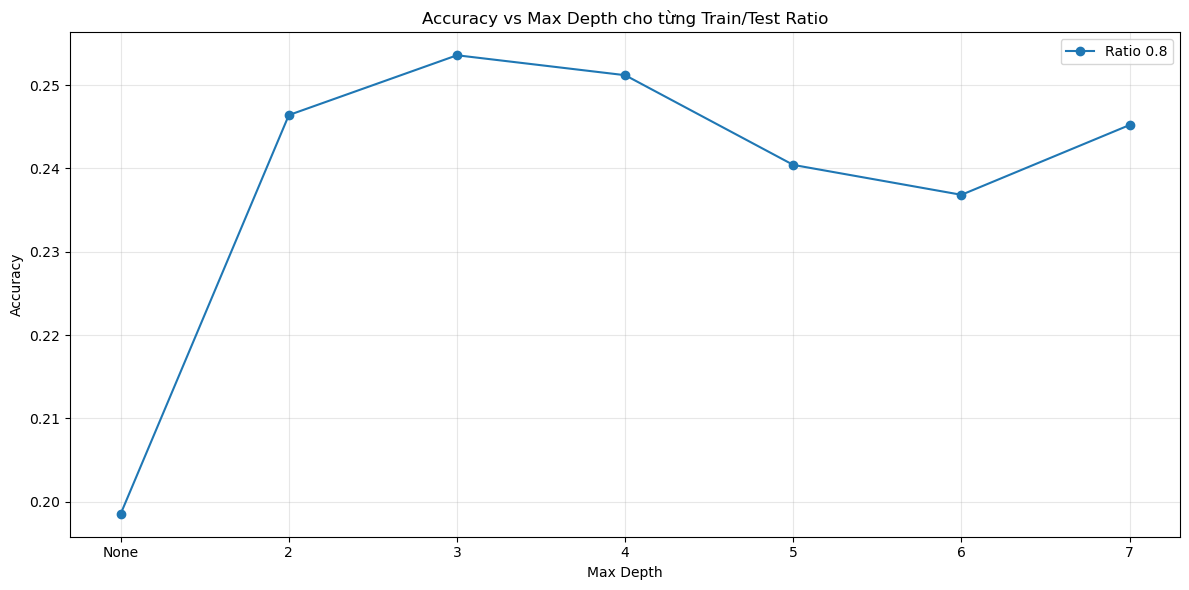

In [13]:
# 4. Biểu đồ và nhận xét
results_df = pd.DataFrame(results)
fig, ax = plt.subplots(figsize=(12, 6))

subset = results_df[results_df['Ratio'] == ratio]
ax.plot(range(len(subset)), subset['Accuracy'], marker='o', label=f'Ratio {ratio}')

ax.set_xticks(range(len(max_depths)))
ax.set_xticklabels([str(d) if d else 'None' for d in max_depths])
ax.set_xlabel('Max Depth')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy vs Max Depth cho từng Train/Test Ratio')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


#### **Nhận xét**

Từ biểu đồ line chart cho tỷ lệ 80/20, ta có thể rút ra những nhận xét quan trọng sau:

- Xu hướng chung (Trend): Biểu đồ cho thấy độ chính xác (Accuracy) đạt đỉnh rất sớm tại độ sâu thấp (max_depth = 3), sau đó có xu hướng giảm nhẹ và đi ngang khi độ sâu tiếp tục tăng. Điều này trái ngược với kỳ vọng thông thường là cây sâu hơn sẽ học tốt hơn.
- Tại độ sâu thấp (max_depth = 2, 3): Mô hình đạt hiệu suất tốt nhất, với Accuracy cao nhất ~25.4% tại max_depth = 3.

$\rightarrow$ Việc giữ cây "nông" giúp mô hình tổng quát hóa tốt hơn, tránh bị nhiễu.
- Tại độ sâu lớn hơn (max_depth = 4, 5, 6, 7): Hiệu suất bắt đầu suy giảm (xuống còn ~23.7% tại max_depth = 6) thay vì tăng lên.
Đây là dấu hiệu của việc Overfitting. Khi cho phép cây mọc sâu hơn, mô hình bắt đầu học thuộc lòng các mẫu nhiễu (noise) đặc thù trong tập huấn luyện thay vì tìm ra quy luật chung, dẫn đến khả năng dự đoán trên tập kiểm thử bị kém đi.
- So sánh với Baseline (max_depth = None):Kết quả khi không giới hạn độ sâu (None) là thấp nhất (~19.8%). Con số này thấp hơn đáng kể so với mức đỉnh 25.4% của cây đã cắt tỉa.

$\rightarrow$ Kết luận: Đối với tập dữ liệu Abalone có độ nhiễu cao, kỹ thuật Pre-pruning (Cắt tỉa sớm) bằng cách giới hạn độ sâu (cụ thể là max_depth = 3) là cực kỳ hiệu quả và cần thiết để tối ưu hóa mô hình.